# Hispasonic EDA — Exploratory Data Analysis

**Source:** `../data/processed/hispasonic_unified.csv`  
**Goal:** Deep exploratory analysis focused on temporal evolution, price dynamics, brand and city patterns, and correlation groups  
**Figures:** Saved automatically to `../reports/figures/`

---

## Analysis plan
1. Dataset overview
2. Temporal evolution — listing volume and price trends over time
3. Price analysis — distribution, outliers, listing type breakdown
4. Brand analysis — top brands, price per brand, brand evolution over time
5. Geographic analysis — top cities, price by city, city activity over time
6. Engagement (`seen`) — distribution, seen vs price, seen by brand
7. Correlation matrix — all numeric variables
8. Cross-group analysis — brand × city, brand × time heatmaps

## 1. Imports, config and figure helper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/hispasonic_unified.csv'
FIGURES_DIR  = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

TOP_N = 15  # number of brands / cities to show in ranked charts

def savefig(name):
    """Save current figure to reports/figures/ and display inline."""
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, dpi=150)
    print(f'Saved → {path}')
    plt.show()

print('Setup complete.')

Setup complete.


## 2. Load dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['published', 'expire', 'date_scrapped'])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range (date_scrapped): {df["date_scrapped"].min().date()} → {df["date_scrapped"].max().date()}')
print(f'Unique brands: {df["synt_brand"].nunique()}')
print(f'Unique cities: {df["city"].nunique()}')
print()
df.head()

Shape: (5962, 17)
Columns: ['urgent', 'buy', 'change', 'sell', 'price', 'gift', 'search', 'repair', 'parts', 'synt_brand', 'description', 'city', 'published', 'expire', 'date_scrapped', 'seen', 'source_file']
Date range (date_scrapped): 2022-08-26 → 2024-05-26
Unique brands: 249
Unique cities: 49



,urgent,buy,change,sell,price,gift,search,repair,parts,synt_brand,description,city,published,expire,date_scrapped,seen,source_file
0,0,0,0,1,350,0,0,0,0,dreadbox,dreadbox nyx v1,Valencia,2022-05-08,2022-09-23,2022-08-26,668,2022_08_26.csv
1,0,0,0,1,350,0,0,0,0,modal electronics,cobalt 5s,Castellón,2022-07-25,2022-09-23,2022-08-26,312,2022_08_26.csv
2,0,0,0,1,900,0,0,0,0,moog,moog little phatty stage 2,Baleares,2021-07-10,2022-09-28,2022-08-26,548,2022_08_26.csv
3,0,0,0,1,420,0,0,0,0,doepfer,último precio doepfer a-100 6u,Málaga,2022-07-01,2022-08-30,2022-08-26,272,2022_08_26.csv
4,0,0,0,1,480,0,0,0,0,mpc,mpc live ssd 250 envío incluido,Albacete,2022-08-26,2022-10-25,2022-08-26,78,2022_08_26.csv


## 3. Temporal evolution

Saved → ../reports/figures/01_listing_volume_over_time.png


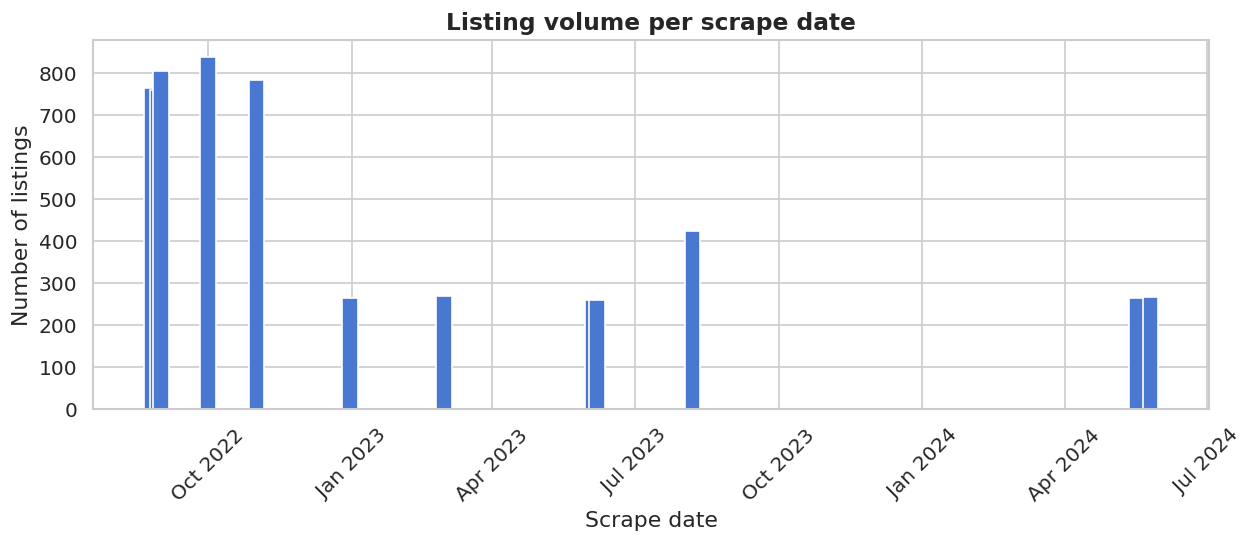

In [3]:
# ── 3a. Listing volume per scrape date ────────────────────────────────────
vol = df.groupby('date_scrapped').size().reset_index(name='listings')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vol['date_scrapped'], vol['listings'], width=10, color=sns.color_palette('muted')[0])
ax.set_title('Listing volume per scrape date', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
savefig('01_listing_volume_over_time')

**Insight — Listing volume per scrape date**

The chart reveals two clearly differentiated periods:

- **High-density phase (Aug–Nov 2022):** the first four sessions each captured 750–840 listings, suggesting either higher scraping frequency or a more populated marketplace at that time.
- **Sustained contraction from Dec 2022 onwards:** subsequent sessions drop to 260–430 listings, roughly half the initial volume. A significant gap with no scraping is visible between Oct 2023 and May 2024.

This irregular cadence must be considered in any temporal analysis: comparing raw listing counts across dates without accounting for the elapsed time between sessions can be misleading.

In [4]:
# ── 3b. Median and mean price evolution over time ─────────────────────────
df_sell = df[df['sell'] == 1].copy()

price_time = df_sell.groupby('date_scrapped')['price'].agg(median='median', 
                                                           mean='mean', 
                                                           q25=lambda x: x.quantile(0.25), 
                                                           q75=lambda x: x.quantile(0.75)
                                                          ).reset_index()

price_time

,date_scrapped,median,mean,q25,q75
0,2022-08-26,300.0,755.981481,115.0,600.00
1,2022-08-30,300.0,742.202296,110.0,600.00
2,2022-09-01,300.0,777.933873,120.0,600.00
3,2022-10-01,310.0,821.815445,120.0,650.00
4,2022-11-01,300.0,704.706294,120.0,700.00
5,2022-12-31,0.0,0.000000,0.0,0.00
6,2023-03-01,0.0,0.000000,0.0,0.00
7,2023-06-04,0.0,0.000000,0.0,0.00
8,2023-06-07,350.0,751.493827,123.0,810.00
9,2023-08-07,350.0,731.505102,140.0,807.50


Saved → ../reports/figures/02_price_evolution_over_time.png


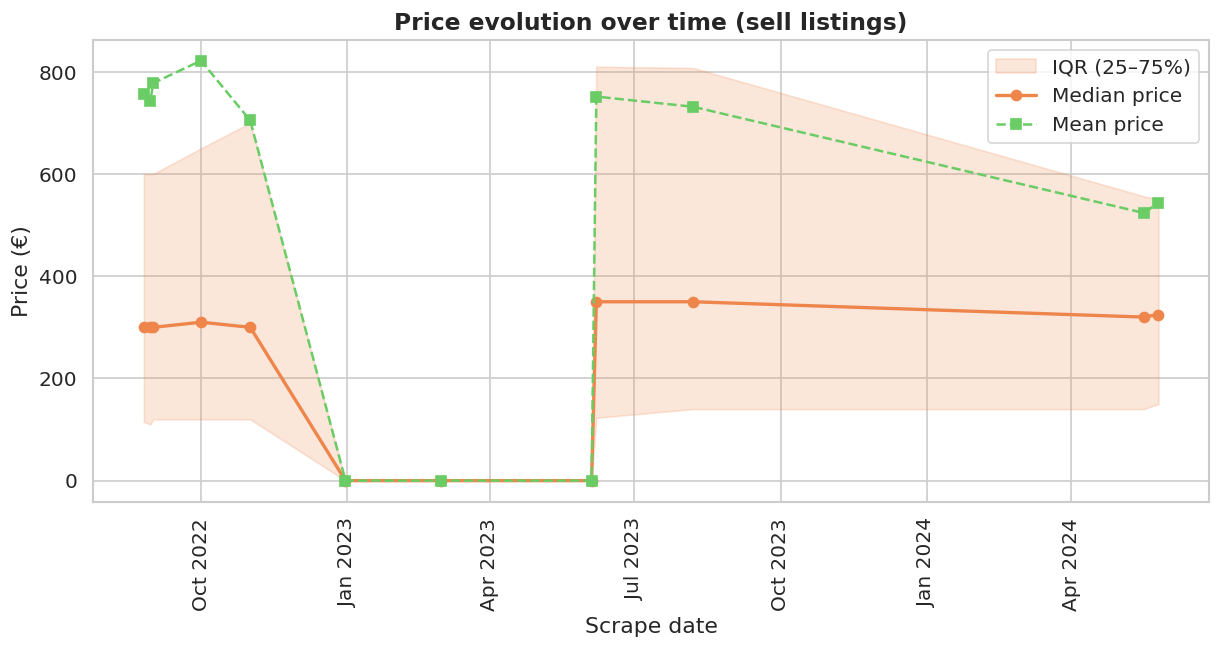

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(price_time['date_scrapped'], 
                price_time['q25'], 
                price_time['q75'],
                alpha=0.2, 
                label='IQR (25–75%)', 
                color=sns.color_palette('muted')[1])

ax.plot(price_time['date_scrapped'], price_time['median'], marker='o', label='Median price',
        color=sns.color_palette('muted')[1], linewidth=2)

ax.plot(price_time['date_scrapped'], price_time['mean'], marker='s', linestyle='--',
        label='Mean price', color=sns.color_palette('muted')[2], linewidth=1.5)

ax.set_title('Price evolution over time (sell listings)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Price (€)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)
ax.legend()
savefig('02_price_evolution_over_time')

**Insight — Price evolution over time (sell listings)**

Three elements are plotted: the **median price** (orange line), the **mean price** (green dashed), and the **interquartile range** IQR 25–75% (shaded area).

- The **median** stays remarkably stable across the entire period, hovering around **300–350 €**, indicating that the typical transaction price barely changed between 2022 and 2024.
- The **mean** (~750–820 € in late 2022, falling to ~520–545 € by 2024) is consistently and significantly higher than the median, a clear sign that a small number of high-value listings (organs, professional synths) pull the average upwards.
- Three sessions (**2022-12-31, 2023-03-01, 2023-06-04**) show both median and mean collapsing to 0 €. This is a **data quality artefact**, not a real market event: those scraping sessions did not capture price information correctly.
- The IQR narrows slightly over time, suggesting the mid-range of the market became more homogeneous in 2023–2024.

Saved → ../reports/figures/03_listing_type_share_over_time.png


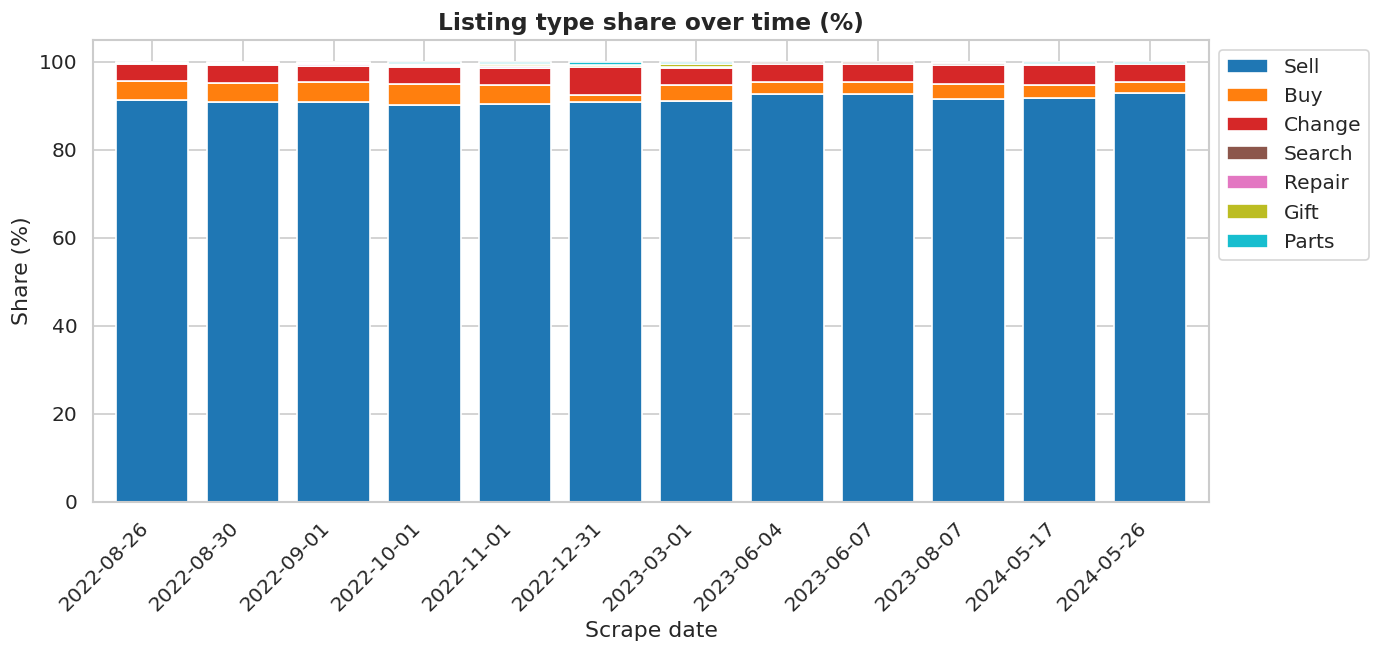

In [6]:
# ── 3c. Listing type share over time ──────────────────────────────────────
type_map = {'sell': 'Sell', 'buy': 'Buy', 'change': 'Change', 'search': 'Search',
            'repair': 'Repair', 'gift': 'Gift', 'parts': 'Parts'}

type_time = df.groupby('date_scrapped')[list(type_map.keys())].sum()
type_time_pct = type_time.div(type_time.sum(axis=1), axis=0) * 100
type_time_pct.columns = type_map.values()

fig, ax = plt.subplots(figsize=(12, 5))
type_time_pct.plot(kind='bar', stacked=True, ax=ax,
                   colormap='tab10', width=0.8)
ax.set_title('Listing type share over time (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Share (%)')
ax.set_xticklabels([str(d.date()) for d in type_time_pct.index], rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('03_listing_type_share_over_time')

**Insight — Listing type share over time**

This stacked bar chart shows the proportional breakdown of listing types (Sell, Buy, Change, Search, Repair, Gift, Parts) for each scraping session.

- **Sell** (blue) dominates overwhelmingly at **~90–95%** in every single session, confirming that Hispasonic functions primarily as a second-hand gear *selling* platform.
- **Change** (red, exchange/trade listings) and **Buy** (orange, wanted ads) each contribute a small but consistent share, typically 2–5% combined.
- Niche types — **Search, Repair, Gift, Parts** — are barely visible at under 1–2%, present but marginal throughout the entire period.
- The relative proportions are **strikingly stable** across all dates and years, meaning the nature of the marketplace did not fundamentally shift between 2022 and 2024. No structural change in user behaviour is detectable from the type distribution alone.
- The slight uptick in **Change** listings visible around 2022-12-31 coincides with the session that had the lowest total volume, so it may reflect sampling noise rather than a real trend.

## 4. Price analysis

Saved → ../reports/figures/04_price_distribution.png


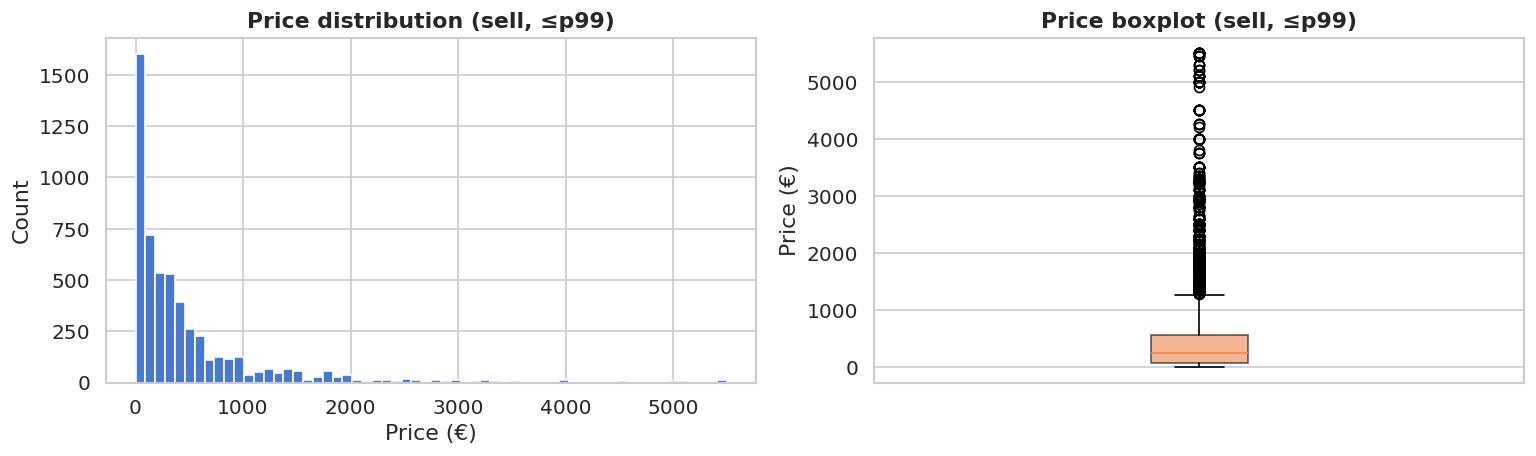

In [7]:
# ── 4a. Price distribution (sell listings, remove extreme outliers) ───────
prices = df_sell['price'].dropna()
p99 = prices.quantile(0.99)
prices_clipped = prices[prices <= p99]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prices_clipped, bins=60, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Price distribution (sell, ≤p99)', fontweight='bold')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')

axes[1].boxplot(prices_clipped, vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.6))
axes[1].set_title('Price boxplot (sell, ≤p99)', fontweight='bold')
axes[1].set_ylabel('Price (€)')
axes[1].set_xticks([])

plt.tight_layout()
savefig('04_price_distribution')

**Insight — Price distribution (sell listings, ≤p99)**

Both the histogram and the boxplot describe the same underlying data — sell listing prices truncated at the 99th percentile (~5,500 €) to remove extreme outliers.

- **Histogram (left):** the distribution is strongly **right-skewed**. The tallest bar sits in the 0–200 € bin (~1,600 listings), and counts decrease rapidly as price rises. This means the vast majority of listings are affordable, everyday second-hand gear. Listings above 1,000 € become relatively infrequent, and those above 3,000 € are rare.
- **Boxplot (right):** confirms the skew visually. The box (IQR, 25th–75th percentile) spans roughly 75–550 €, with a median around 250 €. The large number of dots above the whisker represent **outliers** — high-end instruments such as vintage synthesizers, Hammond organs, or professional studio equipment — that legitimately command prices of 2,000–5,500 €.
- The **47 listings above p99 (> 5,500 €)** were excluded from this view to avoid compressing the scale. Their existence hints at a niche premium segment within the marketplace.

In [8]:
# ── 4b. Price summary stats ───────────────────────────────────────────────
print('=== Price summary (sell listings) ===')
print(prices.describe().round(2))
print(f'\nOutliers above p99 (>{p99:.0f}€): {(prices > p99).sum()} listings')

=== Price summary (sell listings) ===
count      5480.00
mean        636.64
std        3205.27
min           0.00
25%          75.00
50%         250.00
75%         550.00
max      111111.00
Name: price, dtype: float64

Outliers above p99 (>5500€): 47 listings


## 5. Brand analysis

Saved → ../reports/figures/05_top_brands_by_listings.png


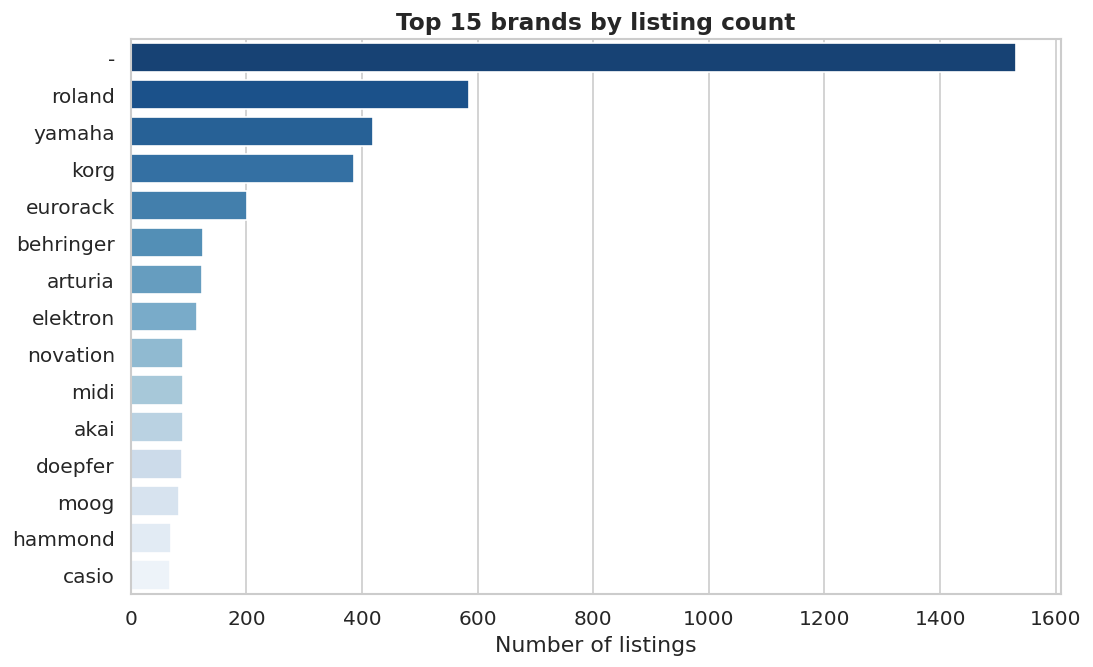

In [9]:
# ── 5a. Top brands by listing count ──────────────────────────────────────
top_brands = df['synt_brand'].value_counts().head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, ax=ax,
            palette='Blues_r')
ax.set_title(f'Top {TOP_N} brands by listing count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of listings')
ax.set_ylabel('')
savefig('05_top_brands_by_listings')

**Insight — Top 15 brands by listing count**

- **"-" leads with ~1,530 listings.** This entry represents listings where no recognisable brand could be extracted from the text (unbranded, generic, or multi-brand descriptions). Its dominance reflects the heterogeneous and free-text nature of marketplace listings — a known limitation of text-based brand detection.
- Among identifiable brands, **Roland** (\~580), **Yamaha** (\~420), and **Korg** (\~390) are the clear top three, consistent with their global market leadership in electronic musical instruments.
- **Eurorack** (\~200 listings) deserves a special note: it is not a manufacturer but a **modular synthesizer format/standard**. It appears here because sellers frequently use the term "Eurorack" in their listings without specifying an individual module maker (e.g. Make Noise, Mutable Instruments, Intellijel). Its presence reflects a thriving modular community on the platform.
- The long tail — Behringer, Arturia, Elektron, Novation, Midi, Akai, Doepfer, Moog, Hammond, Casio — each with under 200 listings, shows that the market is concentrated among a few dominant brands while niche or premium brands have a smaller but dedicated audience.

Saved → ../reports/figures/06_median_price_per_brand.png


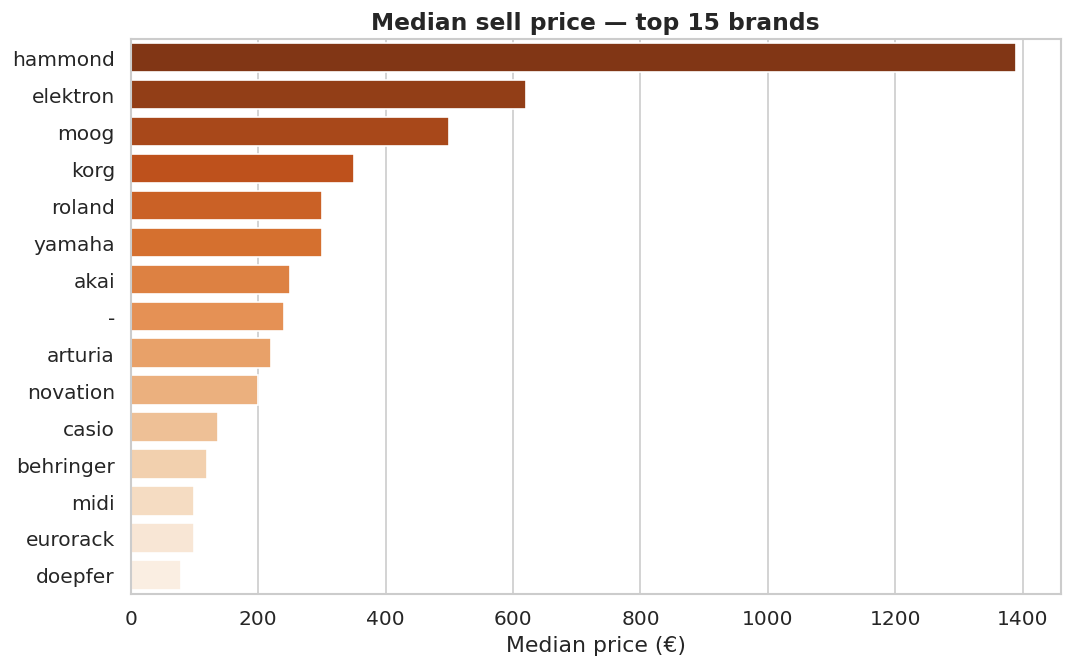

In [10]:
# ── 5b. Median price per top brand ────────────────────────────────────────
brand_price = (
    df_sell[df_sell['synt_brand'].isin(top_brands.index)]
    .groupby('synt_brand')['price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=brand_price.values, y=brand_price.index, hue=brand_price.index, ax=ax, palette='Oranges_r')
ax.set_title(f'Median sell price — top {TOP_N} brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Median price (€)')
ax.set_ylabel('')
savefig('06_median_price_per_brand')

**Insight — Median sell price per brand (top 15)**

This chart inverts the supply ranking: the brands with the most listings are not necessarily the most expensive.

- **Hammond** tops the price ranking at ~1,400 €, a reflection of the iconic and irreplaceable status of vintage Hammond organs among musicians. Low supply (few listings) combined with high perceived value keeps prices elevated.
- **Elektron** (\~620 €) and **Moog** (\~500 €) follow, both representing premium boutique brands with strong resale value among synthesizer enthusiasts.
- **Korg** (\~350 €), **Roland** (\~310 €), and **Yamaha** (\~300 €) land in the mid-range — high-volume brands whose wide product catalogues span both affordable and professional tiers, resulting in a moderate median.
- At the lower end, **Behringer** (\~110 €) is known for producing affordable clones of classic instruments; its low median confirms that buyers primarily trade entry-level units.
- **Doepfer** (\~65 €) and **Eurorack** (\~85 €) show the lowest medians, consistent with trading individual modular modules rather than complete instruments.
- The "-" (unbranded) category sits around 240 €, roughly in line with the overall market median, suggesting that unlabelled listings are typically mid-range items rather than either junk or premium gear.

Saved → ../reports/figures/07_brand_evolution_over_time.png


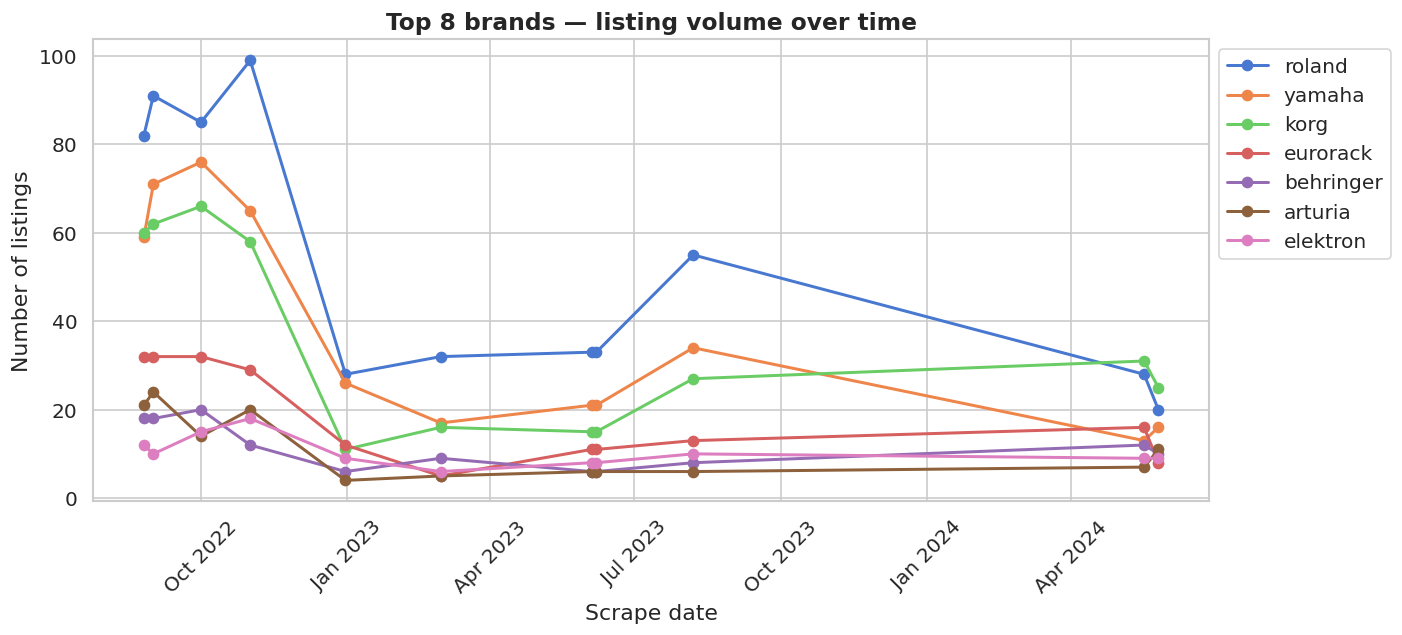

In [11]:
# ── 5c. Brand evolution over time (top 8 brands) ─────────────────────────
top8 = df['synt_brand'].value_counts().head(8).index.tolist()
top8 = [brand for brand in top8 if brand != "-"]
brand_time = (
    df[df['synt_brand'].isin(top8)]
    .groupby(['date_scrapped', 'synt_brand'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for brand in top8:
    if brand in brand_time.columns:
        ax.plot(brand_time.index, brand_time[brand], marker='o', label=brand, linewidth=1.8)
        
ax.set_title('Top 8 brands — listing volume over time', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

savefig('07_brand_evolution_over_time')

Saved → ../reports/figures/08_brand_time_heatmap.png


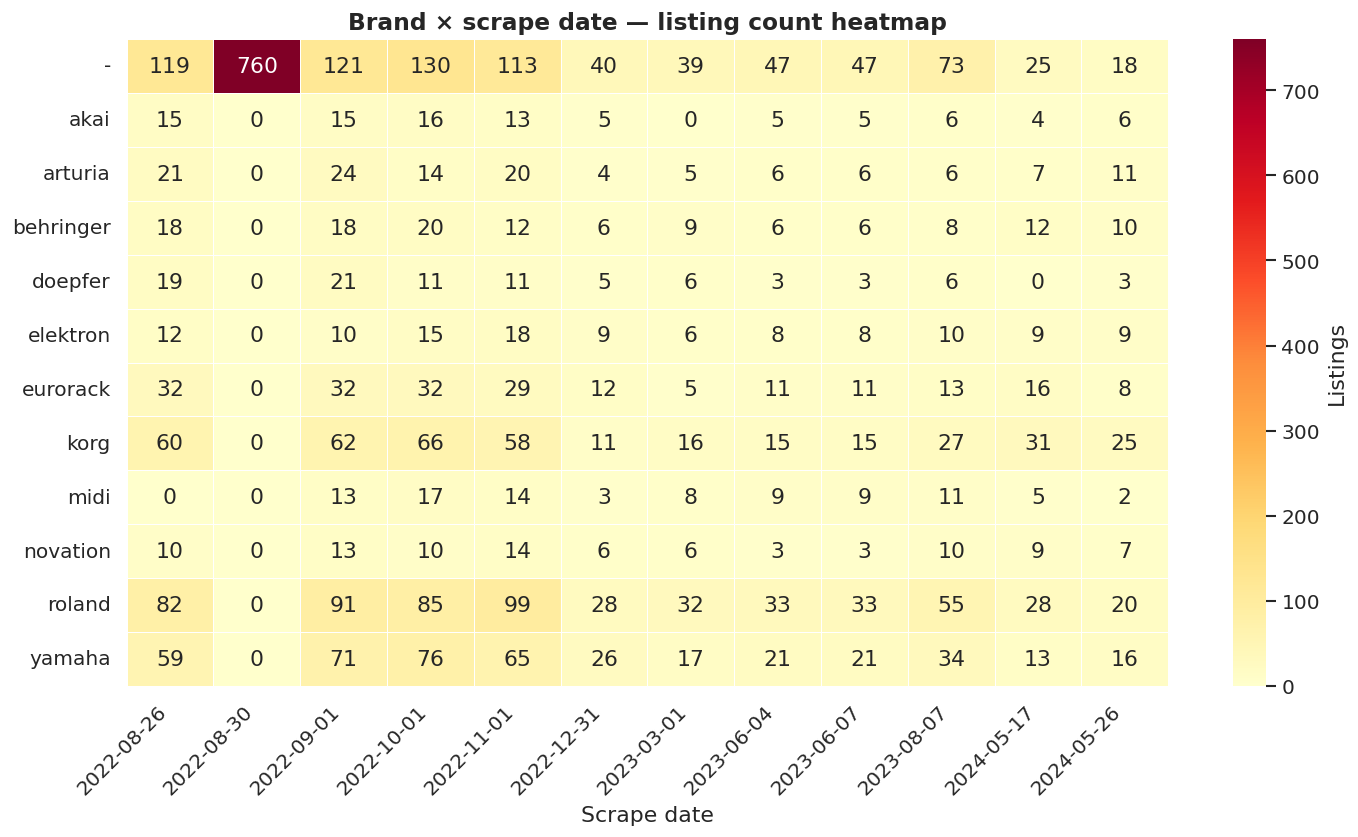

In [12]:
# ── 5d. Brand × time heatmap (listing count) ──────────────────────────────
top12 = df['synt_brand'].value_counts().head(12).index.tolist()
heatmap_data = (
    df[df['synt_brand'].isin(top12)]
    .groupby(['synt_brand', 'date_scrapped'])
    .size()
    .unstack(fill_value=0)
)
heatmap_data.columns = [str(c.date()) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Listings'})
ax.set_title('Brand × scrape date — listing count heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
savefig('08_brand_time_heatmap')

**Insight — Brand × scrape date heatmap**

The heatmap cross-references each brand (rows) against each scraping session (columns), with cell values showing the listing count and colour intensity ranging from pale yellow (low) to dark red (high).

- **"-" row anomaly on 2022-08-30:** the cell shows 760 listings — dramatically higher than any other brand on any other date — while simultaneously all named brands show 0. This is almost certainly a **data quality issue**: the brand extraction logic failed on that session, causing all listings to fall through to the "unidentified" bucket. This date should be excluded or treated with caution in brand-level analyses.
- **Roland** is the most consistently present brand across all sessions (82–99 listings in the late-2022 peak, stabilising at 20–55 afterwards), reinforcing its position as the dominant brand on the platform.
- **Korg** and **Yamaha** follow a similar but slightly lower trajectory, reflecting their comparable market presence.
- The volume drop from late 2022 to 2023+ is visible across all rows, consistent with the overall scraping cadence reduction observed in chart 1.
- **Akai, Novation, Doepfer, Elektron** maintain low but steady listing counts (3–21 per session), indicating a reliable — if niche — user base for these brands throughout the period.

## 6. Geographic analysis

Saved → ../reports/figures/09_top_cities_by_listings.png


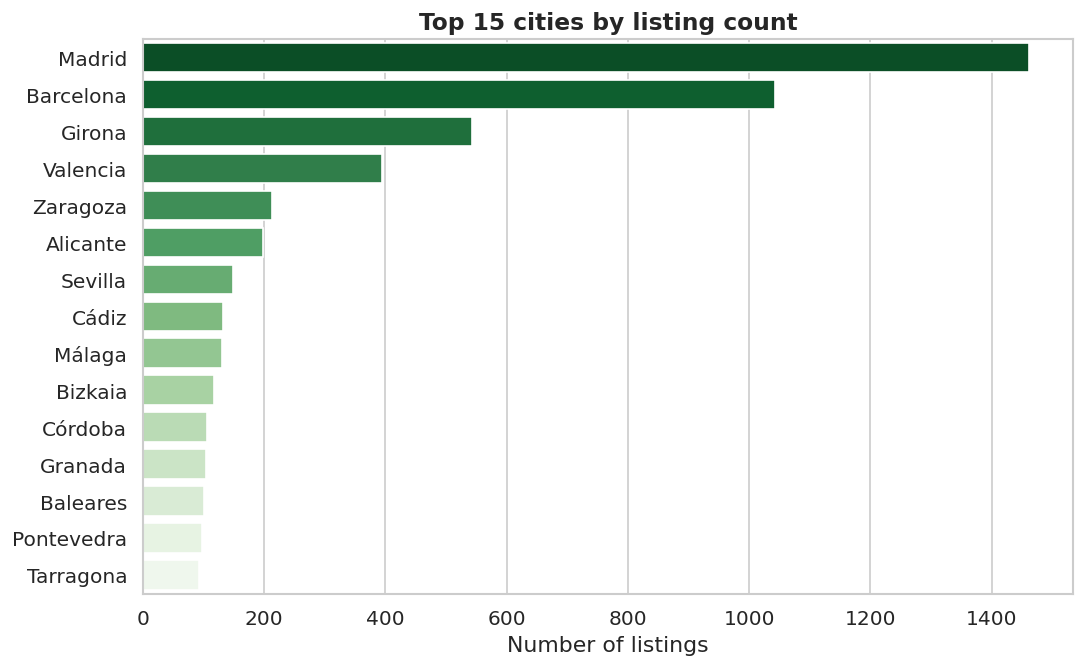

In [13]:
# ── 6a. Top cities by listing count ───────────────────────────────────────
top_cities = df['city'].value_counts().head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, ax=ax, palette='Greens_r')
ax.set_title(f'Top {TOP_N} cities by listing count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of listings')
ax.set_ylabel('')
savefig('09_top_cities_by_listings')

**Insight — Top 15 cities by listing count**

- **Madrid** (\~1,450 listings) and **Barcelona** (\~1,040) account for roughly 42% of the entire dataset between them, reflecting Spain's demographic concentration in these two metropolitan areas.
- **Girona** appears in third place (\~535 listings) — a surprising position for a mid-sized city, which may reflect either a particularly active local seller community or a geographic aggregation artefact (province-level tagging capturing a wider area).
- **Valencia** (\~390) and **Zaragoza** (\~210) follow at a significant distance.
- The remaining ten cities each contribute under 200 listings, forming a long tail of smaller regional markets.

Read together with the median price chart below, this volume ranking is notably **inverse to the price ranking** — see the next insight for the combined interpretation.

Saved → ../reports/figures/10_median_price_per_city.png


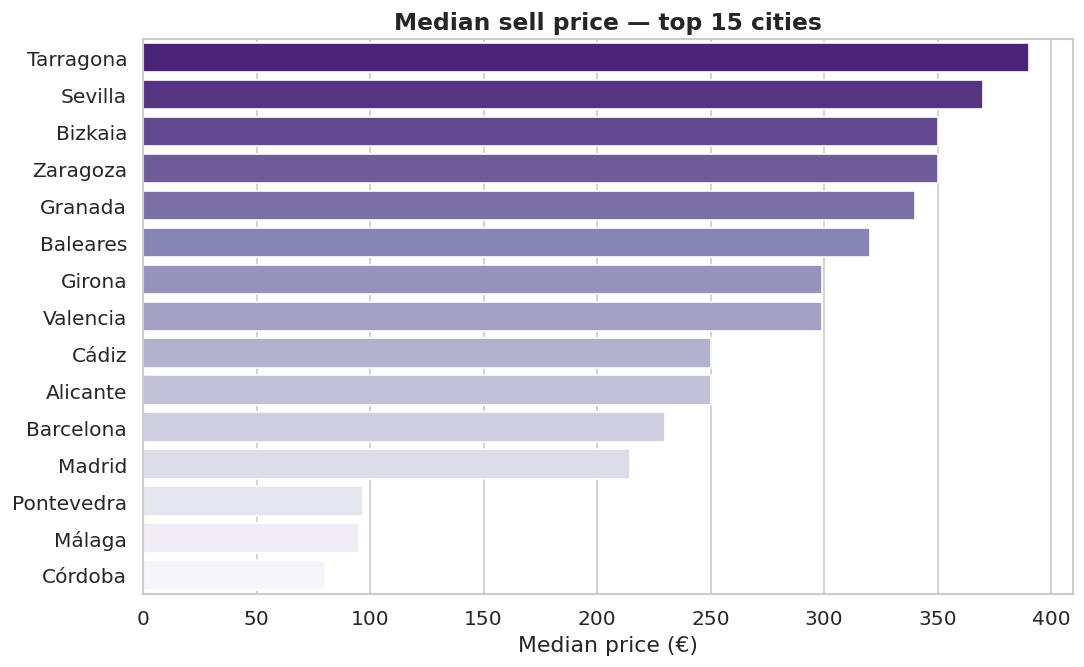

In [14]:
# ── 6b. Median sell price by top city ────────────────────────────────────
city_price = (
    df_sell[df_sell['city'].isin(top_cities.index)]
    .groupby('city')['price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=city_price.values, y=city_price.index, hue=city_price.index,ax=ax, palette='Purples_r')
ax.set_title(f'Median sell price — top {TOP_N} cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Median price (€)')
ax.set_ylabel('')
savefig('10_median_price_per_city')

**Insight — Median sell price by city, and its relationship with listing volume**

Comparing this chart with the listing-count ranking reveals a **counterintuitive inverse relationship**:

| City | Listing count rank | Median price |
|---|---|---|
| Madrid | 1st (~1,450) | ~215 € (low) |
| Barcelona | 2nd (~1,040) | ~230 € (low) |
| Tarragona | 15th (lowest volume) | ~390 € (highest price) |
| Sevilla | 7th | ~370 € |
| Bizkaia | 10th | ~350 € |

- **High-volume cities (Madrid, Barcelona) show lower median prices.** Greater competition and a wider variety of listings — including many cheap items — compress the median downward.
- **Low-volume cities tend to show higher median prices.** Sellers in smaller markets may self-select toward higher-value items (it is worth advertising an expensive piece remotely), or there is simply less price pressure due to fewer competing listings.
- **Girona** is an exception: high volume (3rd) yet a relatively high median (~300 €), possibly due to a concentration of premium-brand sellers in that area.
- This price-volume divergence is a useful signal for any demand model: raw listing count is not a reliable proxy for market quality or value.

Saved → ../reports/figures/11_city_evolution_over_time.png


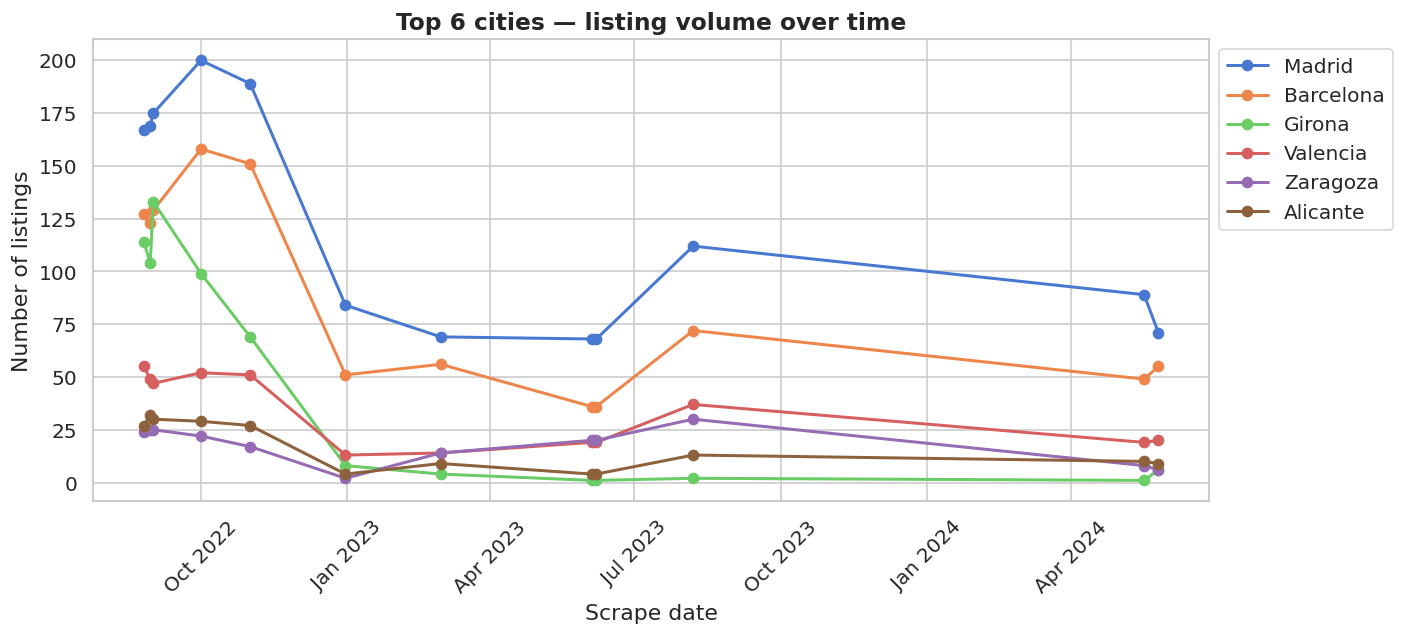

In [15]:
# ── 6c. City activity over time (top 6) ───────────────────────────────────
top6_cities = df['city'].value_counts().head(6).index.tolist()
city_time = (
    df[df['city'].isin(top6_cities)]
    .groupby(['date_scrapped', 'city'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for city in top6_cities:
    if city in city_time.columns:
        ax.plot(city_time.index, city_time[city], marker='o', label=city, linewidth=1.8)
ax.set_title('Top 6 cities — listing volume over time', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('11_city_evolution_over_time')

**Insight — Top 6 cities — listing volume over time**

- **Madrid** (blue) dominates consistently and best illustrates the overall market rhythm: a peak of ~200 listings in Oct 2022, dropping to ~65–85 through early 2023, a partial recovery to ~110 in mid-2023, then stabilising around 85–100 by 2024.
- **Barcelona** (orange) mirrors Madrid's pattern at roughly half the volume, maintaining a more gradual decline.
- **Girona** (green) stands out for a dramatic collapse: from ~130 listings in the 2022 peak to near zero by Jan 2023, with no meaningful recovery. This drop is disproportionate compared to other cities and may reflect a local data capture issue rather than a genuine market exit.
- **Valencia, Zaragoza, and Alicante** remain at low, relatively flat volumes throughout, confirming their role as secondary regional markets with modest but steady activity.
- The general convergence of all cities to lower volumes post-2022 is consistent with the overall scraping frequency reduction, not necessarily a real decline in market activity.

## 7. Engagement — `seen` analysis

Saved → ../reports/figures/12_seen_distribution.png


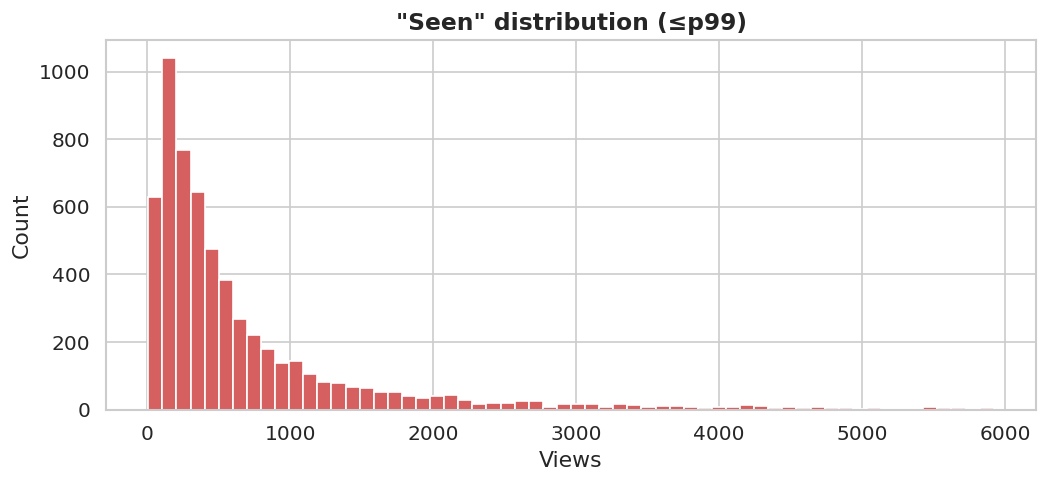

In [16]:
# ── 7a. Seen distribution ─────────────────────────────────────────────────
seen = df['seen'].dropna()
seen_p99 = seen.quantile(0.99)
seen_clipped = seen[seen <= seen_p99]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seen_clipped, bins=60, color=sns.color_palette('muted')[3], edgecolor='white')
ax.set_title('"Seen" distribution (≤p99)', fontsize=14, fontweight='bold')
ax.set_xlabel('Views')
ax.set_ylabel('Count')
savefig('12_seen_distribution')

**Insight — "Seen" distribution (views per listing, ≤p99)**

The histogram shows the distribution of view counts across all listings, clipped at the 99th percentile (~6,000 views).

- The distribution is **strongly right-skewed**, following a pattern typical of online marketplace engagement: most listings attract modest attention while a small minority go "viral".
- The peak occurs around **100–300 views**, meaning the median listing receives only a few hundred views over its lifetime.
- View counts drop rapidly above 500 and become increasingly rare above 1,500–2,000.
- Only a handful of listings exceed 4,000–6,000 views — these are likely highly sought-after items, viral posts, or listings that remained active for a very long time accumulating views.
- The shape suggests that **engagement is highly concentrated**: the top 10% of listings by views likely capture a disproportionate share of total platform traffic, a common Pareto-like pattern in digital marketplaces.

Saved → ../reports/figures/13_price_vs_seen_scatter.png


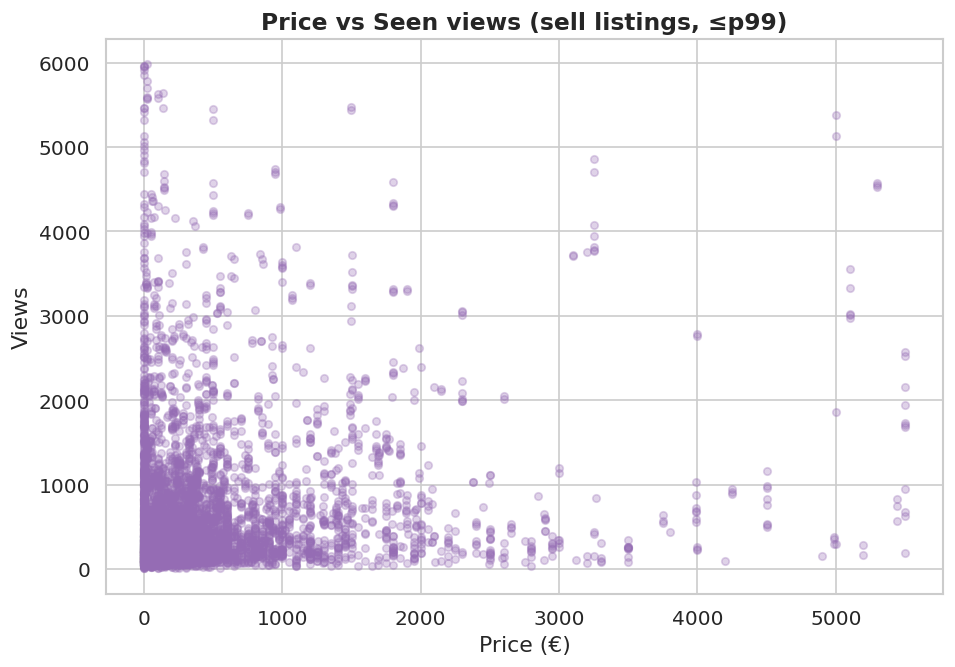

In [17]:
# ── 7b. Seen vs price scatter ─────────────────────────────────────────────
scatter_df = df_sell[['price', 'seen']].dropna()
scatter_df = scatter_df[
    (scatter_df['price'] <= scatter_df['price'].quantile(0.99)) &
    (scatter_df['seen']  <= scatter_df['seen'].quantile(0.99))
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['price'], scatter_df['seen'], alpha=0.3, s=20,
           color=sns.color_palette('muted')[4])
ax.set_title('Price vs Seen views (sell listings, ≤p99)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (€)')
ax.set_ylabel('Views')
savefig('13_price_vs_seen_scatter')

**Insight — Price vs Seen views (scatter plot)**

Each point represents a sell listing, plotted by its price (x-axis) and its view count (y-axis), both clipped at p99.

- The densest cluster sits in the **bottom-left quadrant** (price 0–500 €, views 0–1,000), confirming that cheap listings are the most common and also tend to be the most viewed in absolute terms — simply because there are more of them.
- **The vertical band near price = 0** contains several high-view listings. These are likely listings posted as "price on request" (precio a consultar), which appear at 0 € in the data but can attract high traffic due to curiosity or perceived good deal.
- As price increases, **point density drops sharply** and the maximum view counts reached also tend to fall, suggesting that expensive listings attract a narrower but potentially more targeted audience.
- There is **no clear positive correlation** between price and views. The scatter confirms what the correlation matrix (chart 13) will quantify: the relationship is weak. A high asking price does not attract more views — if anything it may deter casual browsers.
- A few high-priced outliers (> 3,000 €) do achieve 1,000–4,000+ views, indicating that rare, desirable instruments can generate significant interest regardless of price.

Saved → ../reports/figures/14_median_seen_per_brand.png


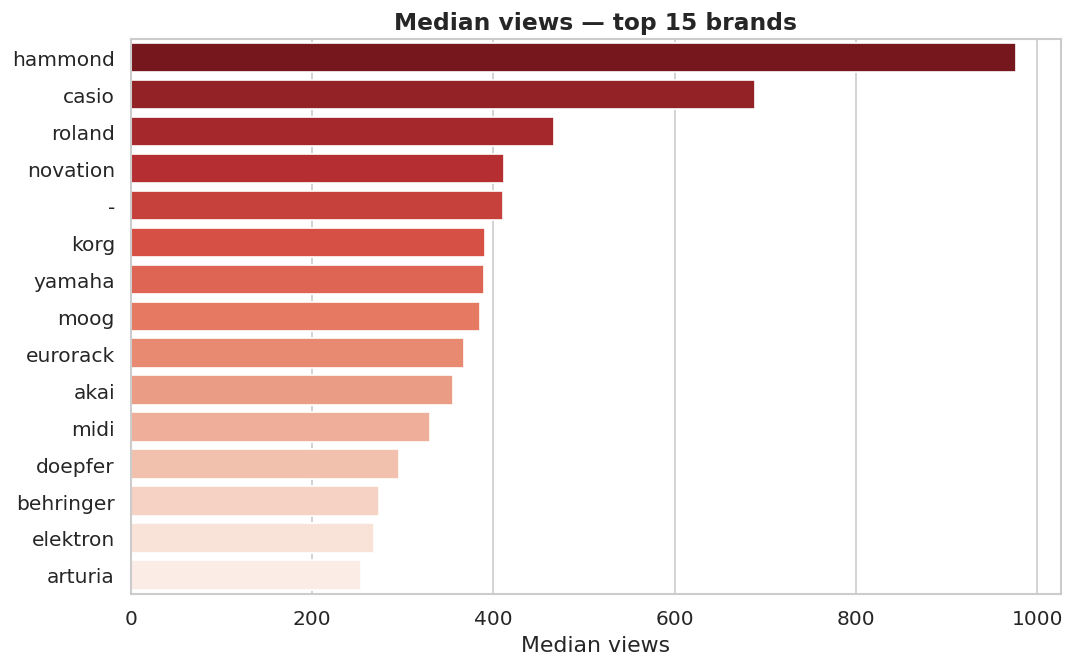

In [18]:
# ── 7c. Median seen by top brand ──────────────────────────────────────────
brand_seen = (
    df[df['synt_brand'].isin(top_brands.index)]
    .groupby('synt_brand')['seen']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=brand_seen.values, y=brand_seen.index, hue=brand_seen.index, ax=ax, palette='Reds_r')
ax.set_title(f'Median views — top {TOP_N} brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Median views')
ax.set_ylabel('')
savefig('14_median_seen_per_brand')

## 8. Correlation matrix

Saved → ../reports/figures/15_correlation_matrix.png


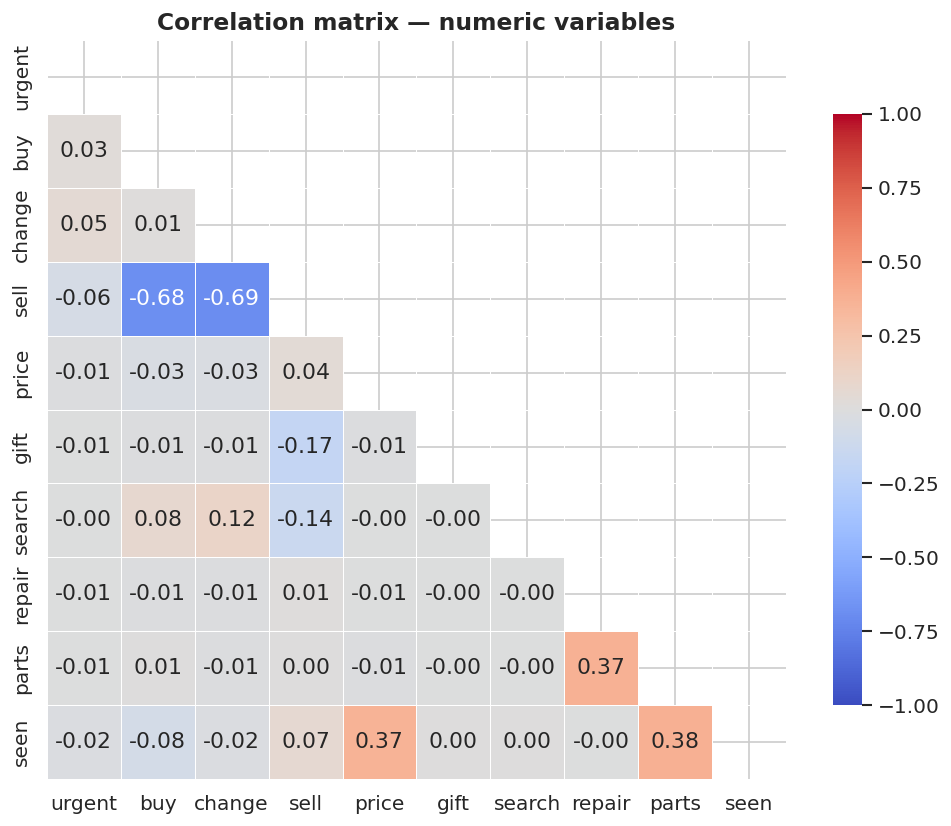

In [19]:
# ── 8a. Full numeric correlation heatmap ─────────────────────────────────
num_cols = ['urgent', 'buy', 'change', 'sell', 'price', 'gift',
            'search', 'repair', 'parts', 'seen']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — numeric variables', fontsize=14, fontweight='bold')
savefig('15_correlation_matrix')

**Insight — Correlation matrix (numeric variables)**

The lower-triangular heatmap shows Pearson correlations between all numeric variables. Values range from –1 (perfect negative) to +1 (perfect positive); values near 0 indicate no linear relationship. Colours shift from blue (negative) through grey (near zero) to red (positive).

**Strong correlations (by design):**
- `sell` ↔ `buy` = **–0.68** and `sell` ↔ `change` = **–0.69**: these are strongly negative because the listing type columns are mutually exclusive flags — a listing is *either* a sale *or* a purchase request *or* a trade. The high magnitude is expected and simply reflects the encoding scheme, not any meaningful market insight.

**Moderate correlations (of interest):**
- `price` ↔ `seen` = **+0.37**: the most analytically interesting relationship. Higher-priced listings receive somewhat more views, possibly because they represent more desirable or aspirational items that attract window-shoppers, not just serious buyers.
- `repair` ↔ `parts` = **+0.37**: listings tagged as repairs co-occur with parts listings, which makes practical sense — people fixing instruments also look for components.
- `parts` ↔ `seen` = **+0.38**: parts listings attract relatively more views, likely because a single spare part can satisfy multiple potential buyers simultaneously, broadening the interested audience.

**Near-zero correlations (most pairs):** the majority of variable pairs show correlations close to 0, meaning the dataset's numeric features are largely independent of each other — a positive sign for modelling, as it reduces multicollinearity risk.

## 9. Cross-group analysis

Saved → ../reports/figures/16_brand_city_heatmap.png


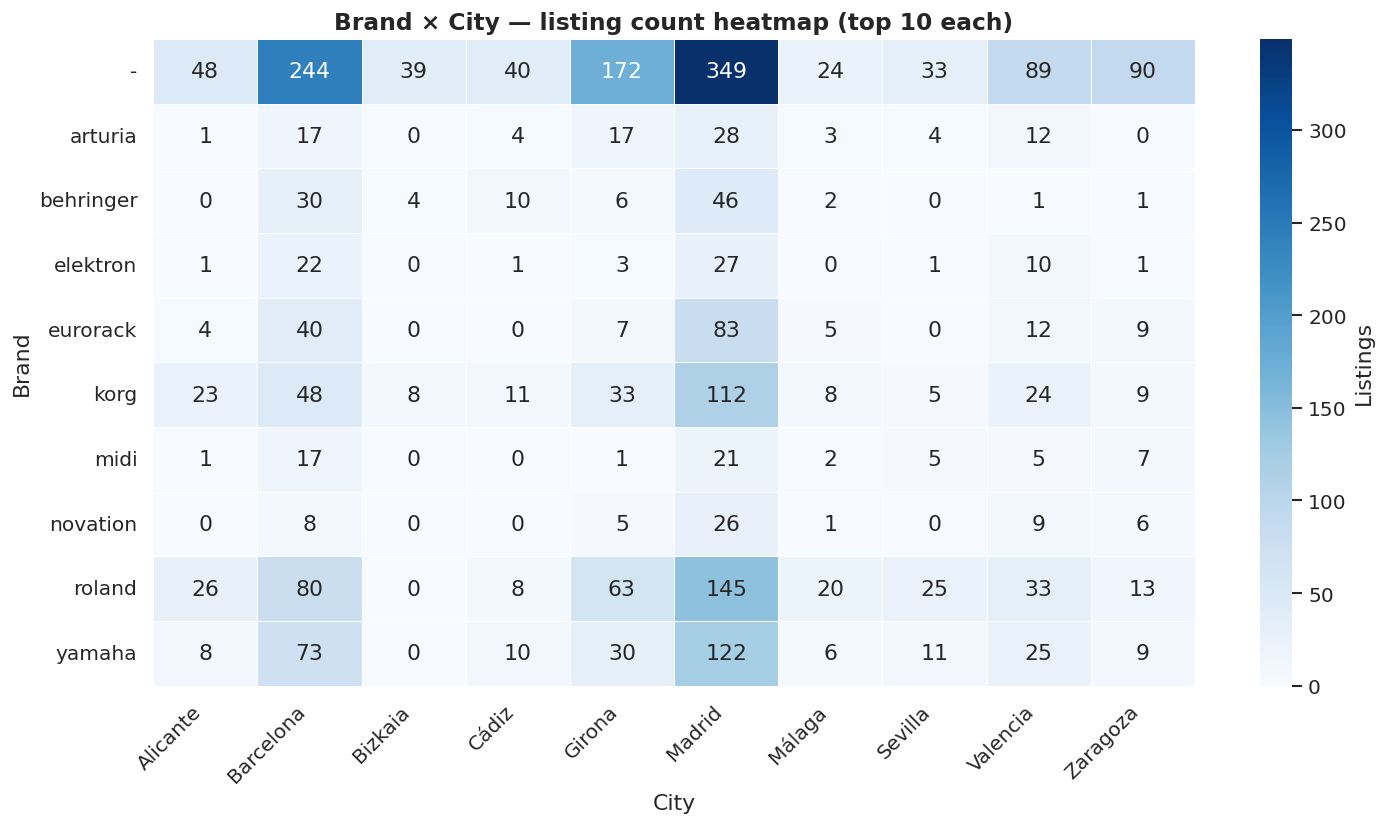

In [20]:
# ── 9a. Brand × city heatmap (listing count, top 10 each) ─────────────────
top10_brands = df['synt_brand'].value_counts().head(10).index.tolist()
top10_cities = df['city'].value_counts().head(10).index.tolist()

cross = (
    df[df['synt_brand'].isin(top10_brands) & df['city'].isin(top10_cities)]
    .groupby(['synt_brand', 'city'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Listings'})
ax.set_title('Brand × City — listing count heatmap (top 10 each)', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Brand')
plt.xticks(rotation=45, ha='right')
savefig('16_brand_city_heatmap')

**Insight — Brand × City heatmap (top 10 each)**

This heatmap shows how listings from the top 10 brands are distributed across the top 10 cities. Darker blue = more listings.

- **Madrid** is the darkest column for virtually every brand, confirming its role as the dominant national market. It hosts the highest counts of Roland (145), Yamaha (122), Korg (112), and Eurorack (83) listings.
- **Barcelona** is consistently the second-busiest city, with notable Roland (80), Yamaha (73), and Korg (48) listings.
- **Girona** shows a surprisingly strong presence for an intermediate city, particularly for the unbranded "-" category (172) and Roland (63) — reinforcing the earlier observation that Girona may be a data-label artefact capturing a wider geographic area.
- **Elektron** listings are heavily concentrated in Madrid and Barcelona (27 and 22 respectively) with minimal presence elsewhere, reflecting its premium positioning and the tendency for boutique gear buyers to cluster in large cities.
- **Behringer** has a notably broad but modest national distribution, appearing across almost all cities — consistent with its role as an accessible, mass-market brand.
- **Bizkaia, Cádiz, and Málaga** show close to zero listings for most brands, confirming their status as peripheral markets in this dataset.

Saved → ../reports/figures/17_price_by_brand_and_type.png


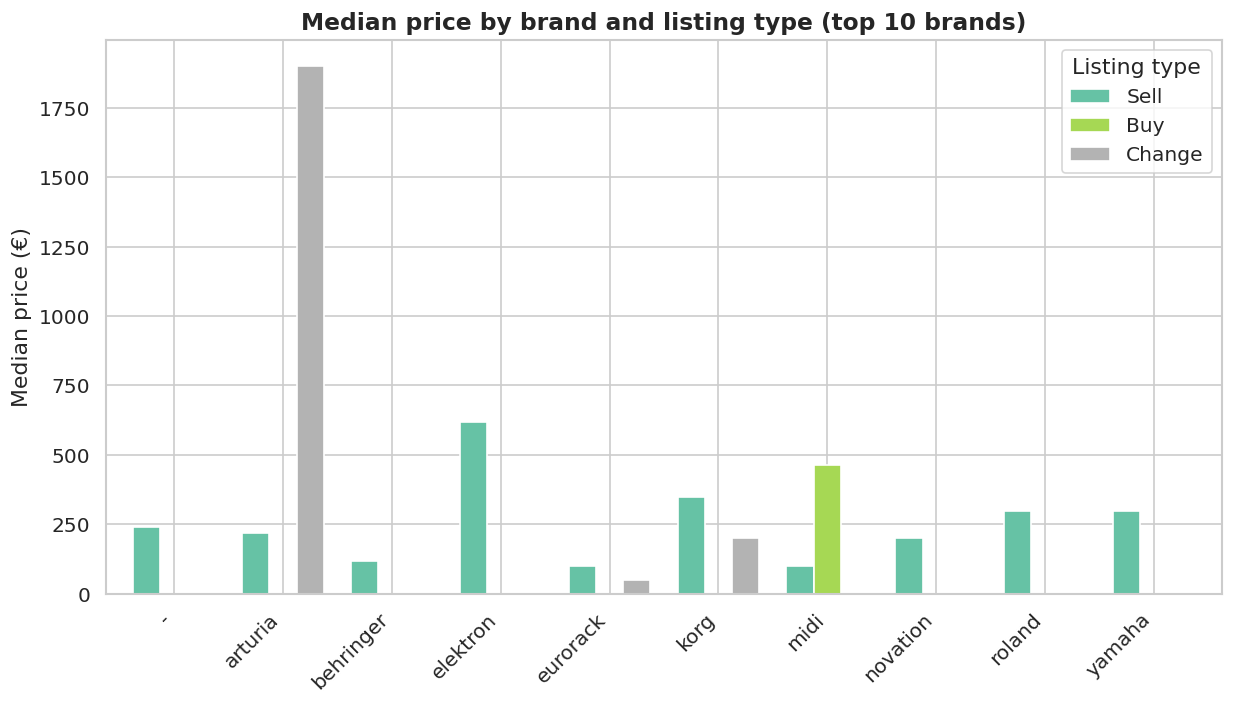

In [21]:
# ── 9b. Median price by brand × listing type ──────────────────────────────
type_cols   = ['sell', 'buy', 'change']
price_pivot = []

for t in type_cols:
    sub = df[(df[t] == 1) & (df['synt_brand'].isin(top10_brands))]
    med = sub.groupby('synt_brand')['price'].median().rename(t.capitalize())
    price_pivot.append(med)

price_pivot_df = pd.concat(price_pivot, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
price_pivot_df.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Median price by brand and listing type (top 10 brands)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Median price (€)')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Listing type')
savefig('17_price_by_brand_and_type')

**Insight — Median price by brand and listing type (top 10 brands)**

This grouped bar chart breaks down the median price for each brand by listing type: **Sell** (green), **Buy** (yellow-green), and **Change** (grey).

- **Behringer — Change** stands out dramatically at ~1,875 €. This means that when Behringer equipment appears in a trade/exchange listing, the items involved are of very high value. A plausible explanation is "trade-up" dynamics: a seller offers multiple Behringer items or a bundle in exchange for a single high-end piece, resulting in a high aggregate valuation.
- **Elektron — Sell** has the highest sell-type median (\~620 €) among all brands shown, consistent with the brand-level price chart.
- **Midi — Buy** shows a ~450 € median, suggesting that buyers searching for MIDI equipment are targeting professional controllers or MIDI-capable synthesisers rather than cheap MIDI interfaces.
- **Korg — Change** (\~200 €) and **Eurorack — Change** (\~50 €) reflect much lower exchange valuations, in line with the lower price tier of their typical products.
- For most brands the **Sell** bar is the tallest or most visible, as the sell type dominates the dataset volume and provides the most reliable median estimate.
- The **absence of Buy and Change bars** for several brands simply means those brands had no (or very few) buy/change listings in the top-10 subset.

Saved → ../reports/figures/18_price_evolution_by_brand.png


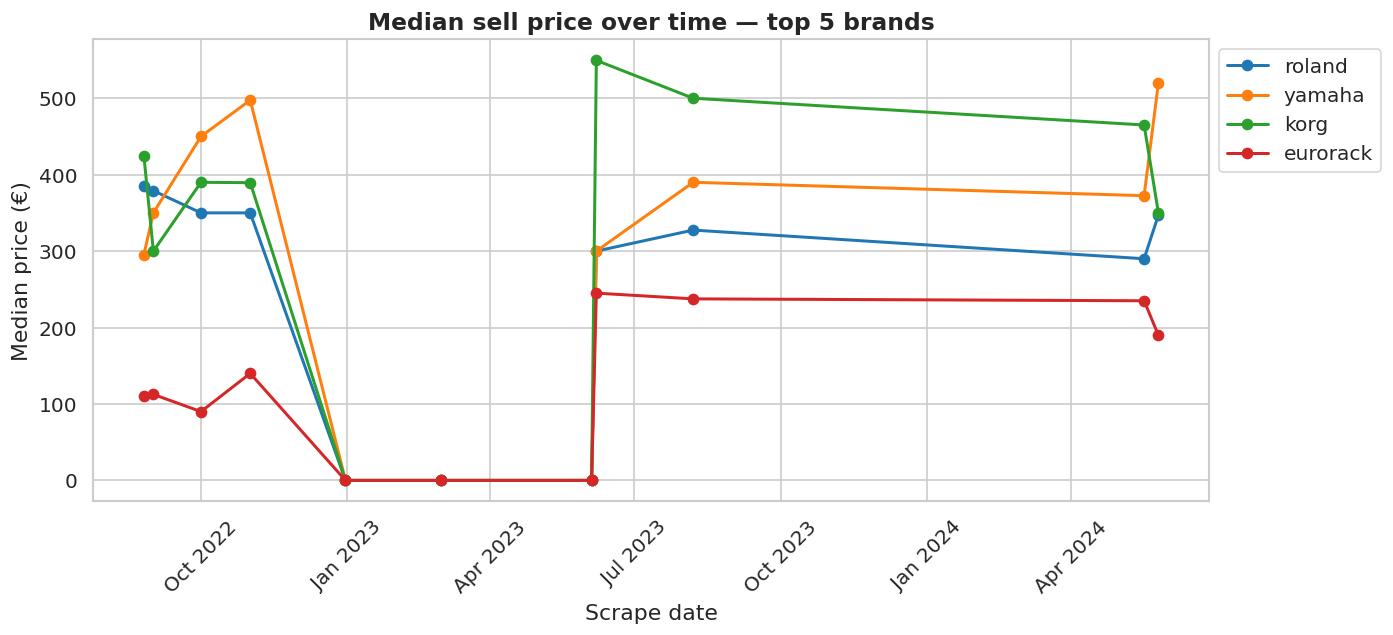

In [22]:
# ── 9c. Price evolution by top 5 brands over time ────────────────────────
top5 = df_sell['synt_brand'].value_counts().head(5).index.tolist()
top5 = [brand for brand in top5 if brand != "-"]

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', n_colors=5)

for i, brand in enumerate(top5):
    sub = df_sell[df_sell['synt_brand'] == brand].groupby('date_scrapped')['price'].median()
    ax.plot(sub.index, sub.values, marker='o', label=brand,
            color=palette[i], linewidth=1.8)

ax.set_title('Median sell price over time — top 5 brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Median price (€)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('18_price_evolution_by_brand')

**Insight — Median sell price over time (top 5 brands)**

This line chart tracks how the median sell price evolved for Roland, Yamaha, Korg, and Eurorack across scraping sessions.

- **Korg** (green) commands the highest median price throughout (~300–550 €), peaking sharply at ~550 € in mid-2023 and maintaining ~350–470 € by 2024. This reflects a strong collector and producer demand for Korg synthesizers.
- **Yamaha** (orange) is the most volatile: it reaches ~500 € in Oct 2022, then collapses to near 0 in the three problematic sessions (Dec 2022 – Jun 2023) before recovering to ~370–520 € in 2024. The recovery at higher values may suggest a composition shift toward more expensive Yamaha models in later scrapes.
- **Roland** (blue) is the most price-stable brand, hovering in the narrow range of ~290–400 € across the entire period — a sign of a liquid, competitive resale market where prices are well-anchored.
- **Eurorack** (red) sits at the lowest level (~95–250 €), consistent with trading individual modules rather than full instruments. It also shows the zeroed sessions for the same data-quality reason as the others.
- The **collapse to 0 € for all brands between Dec 2022 and Jun 2023** is a confirmed data quality artefact (missing price fields in those scrape files), not a real market event.

---

## Key Takeaways — EDA Summary

1. **Data quality issues are significant.** Three scraping sessions (2022-12-31, 2023-03-01, 2023-06-04) have corrupted price data (all zeros), and the 2022-08-30 session has a broken brand-extraction that assigns all listings to the "-" bucket. Both anomalies must be handled before any modelling.

2. **Hispasonic is overwhelmingly a selling platform.** Over 90% of listings at every point in time are sell-type ads. The marketplace structure is stable and has not shifted meaningfully between 2022 and 2024.

3. **Prices are right-skewed with a stable median around 250–350 €.** The mean (~600–820 €) is systematically inflated by a thin premium segment (Hammond organs, Elektron drum machines, rare synths). Any regression model should use robust estimators or log-transform prices.

4. **Roland, Yamaha, and Korg dominate supply; Hammond, Elektron, and Moog dominate value.** The brands with the highest listing counts are not the most expensive — a clear market segmentation between high-volume affordable brands and low-volume premium brands.

5. **Madrid and Barcelona concentrate volume but not price.** The inverse volume-price relationship across cities suggests that larger markets are more competitive, compressing prices, while smaller markets see more selective, higher-value listings.

6. **Engagement (views) follows a Pareto distribution.** Most listings receive modest attention; a small fraction captures disproportionate traffic. Price and views have only a moderate positive correlation (+0.37), meaning price alone is a weak predictor of visibility.

7. **Eurorack as a category, not a brand, deserves special handling.** Its presence in brand rankings reflects a modular ecosystem that spans hundreds of small manufacturers. Treating it as a single brand underestimates its true diversity and may distort brand-level analyses.

8. **The dataset covers nearly 2 years but with irregular cadence.** Any time-series analysis must account for uneven sampling intervals, and volume trends should be interpreted as artefacts of scraping frequency as much as real market dynamics.

## 10. Summary

In [23]:
figs = sorted(os.listdir(FIGURES_DIR))
print(f'{len(figs)} figures saved to {os.path.abspath(FIGURES_DIR)}:')
for f in figs:
    if f.endswith('.png'):
        print(f'  {f}')

28 figures saved to /home/ion/dev/github/hispasonic/reports/figures:
  01_listing_volume_over_time.png
  02_price_evolution_over_time.png
  03_listing_type_share_over_time.png
  04_price_distribution.png
  05_top_brands_by_listings.png
  06_median_price_per_brand.png
  07_brand_evolution_over_time.png
  08_brand_time_heatmap.png
  09_top_cities_by_listings.png
  10_median_price_per_city.png
  11_city_evolution_over_time.png
  12_seen_distribution.png
  13_price_vs_seen_scatter.png
  14_median_seen_per_brand.png
  15_correlation_matrix.png
  16_brand_city_heatmap.png
  17_price_by_brand_and_type.png
  18_price_evolution_by_brand.png
  19_supply_vs_demand_by_city.png
  20_sd_ratio_ranking_by_city.png
  21_sd_ratio_vs_price_scatter.png
  22_sd_ratio_and_price_dual_axis.png
  23_supply_demand_over_time_by_city.png
  24_sd_ratio_evolution_by_city.png
  25_global_supply_demand_ratio_price.png
  26_seen_vs_price_by_city.png
  27_lagged_correlation_sd_ratio_vs_price.png
